# EDA — Vacancies 2026 Salary Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test_x.csv')

print(f'train: {train.shape}  |  test: {test.shape}')

train: (49051, 26)  |  test: (12263, 25)


### 1. Schema & Dtypes

In [2]:
train.dtypes.to_frame('dtype').assign(
    nunique=train.nunique(),
    null_pct=(train.isnull().mean() * 100).round(2),
    sample=train.iloc[0]
)

,dtype,nunique,null_pct,sample
id,int64,49051,0.00,49443602
name,str,24639,0.00,Помощник в мастерскую (производство кожгалантереи премиум класса)
employer_name,str,23392,0.00,Кутузова Юлия Евгеньевна
experience_name,str,4,0.00,Нет опыта
schedule_name,str,5,0.00,Полный день
key_skills_name,str,2610,0.00,шитьё
accept_handicapped,bool,2,0.00,True
accept_kids,bool,2,0.00,False
unified_address_city,str,207,23.46,Москва
unified_address_state,str,84,0.00,Москва


### 2. Target Distribution (`salary_mean_net`)

In [3]:
y = train['salary_mean_net'].dropna()

print('=== salary_mean_net ===')
print(y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(0))
print(f'\nSkewness : {y.skew():.3f}')
print(f'Kurtosis : {y.kurt():.3f}')
print(f'Zeros    : {(y == 0).sum()}')
print(f'Negatives: {(y < 0).sum()}')

=== salary_mean_net ===
count     49051.0
mean      51095.0
std       29618.0
min       10932.0
1%        13485.0
5%        19500.0
25%       30000.0
50%       42920.0
75%       64000.0
95%      110000.0
99%      150000.0
max      195750.0
Name: salary_mean_net, dtype: float64

Skewness : 1.528
Kurtosis : 2.718
Zeros    : 0
Negatives: 0


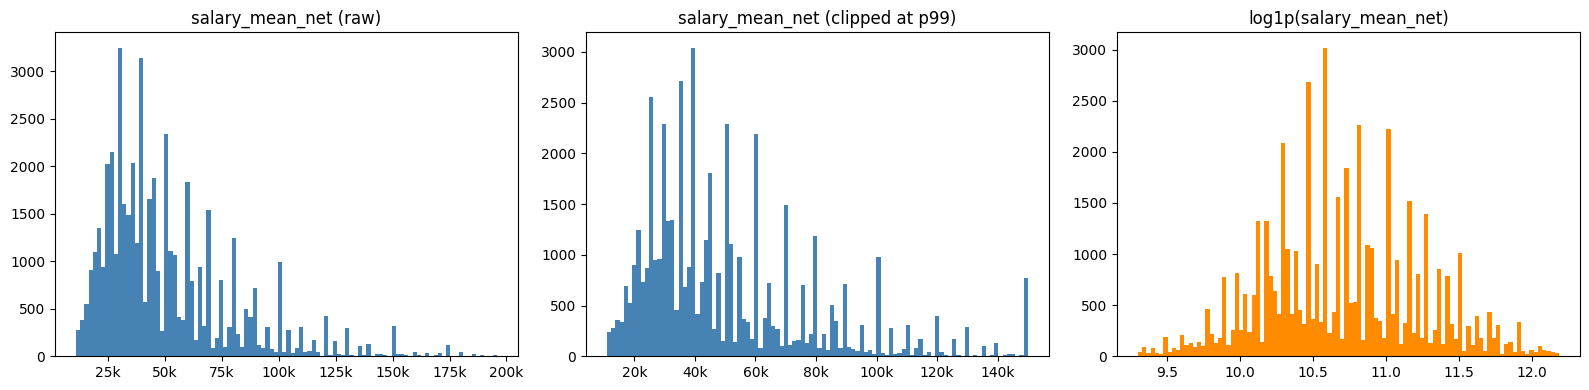

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('salary_mean_net (raw)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

y_clip = y.clip(upper=y.quantile(0.99))
axes[1].hist(y_clip, bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('salary_mean_net (clipped at p99)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

axes[2].hist(np.log1p(y), bins=100, color='darkorange', edgecolor='none')
axes[2].set_title('log1p(salary_mean_net)')

plt.tight_layout()
plt.show()

### 3. Missing Values

In [5]:
null_df = pd.DataFrame({
    'train_null_%': (train.isnull().mean() * 100).round(2),
    'test_null_%' : (test.isnull().mean()  * 100).round(2),
}).query('`train_null_%` > 0 or `test_null_%` > 0').sort_values('train_null_%', ascending=False)

print(null_df.to_string())

                                                train_null_%  test_null_%
lemmaized_wo_stopwords_raw_branded_description         91.87        91.97
raw_branded_description                                91.87        91.97
unified_address_city                                   23.46        23.04
employer_id                                             0.09         0.09
unified_address_region                                  0.01         0.01


### 4. Cardinality of Categorical Features

In [6]:
obj_cols = train.select_dtypes('object').columns.tolist()
card_df = pd.DataFrame({
    'train_nunique': train[obj_cols].nunique(),
    'test_nunique' : test[[c for c in obj_cols if c in test.columns]].nunique(),
    'train_null_%' : (train[obj_cols].isnull().mean() * 100).round(2),
}).sort_values('train_nunique', ascending=False)

print(card_df.to_string())

                                                train_nunique  test_nunique  train_null_%
raw_description                                         42344         11458          0.00
lemmaized_wo_stopwords_raw_description                  42145         11414          0.00
name                                                    24639          7597          0.00
employer_name                                           23392          7734          0.00
name_clean                                              23259          7326          0.00
raw_branded_description                                  3423           922         91.87
lemmaized_wo_stopwords_raw_branded_description           3356           912         91.87
key_skills_name                                          2610          1248          0.00
employer_industries                                       250           213          0.00
unified_address_city                                      207           202         23.46
profession

### 5. Low-Cardinality Features vs Target

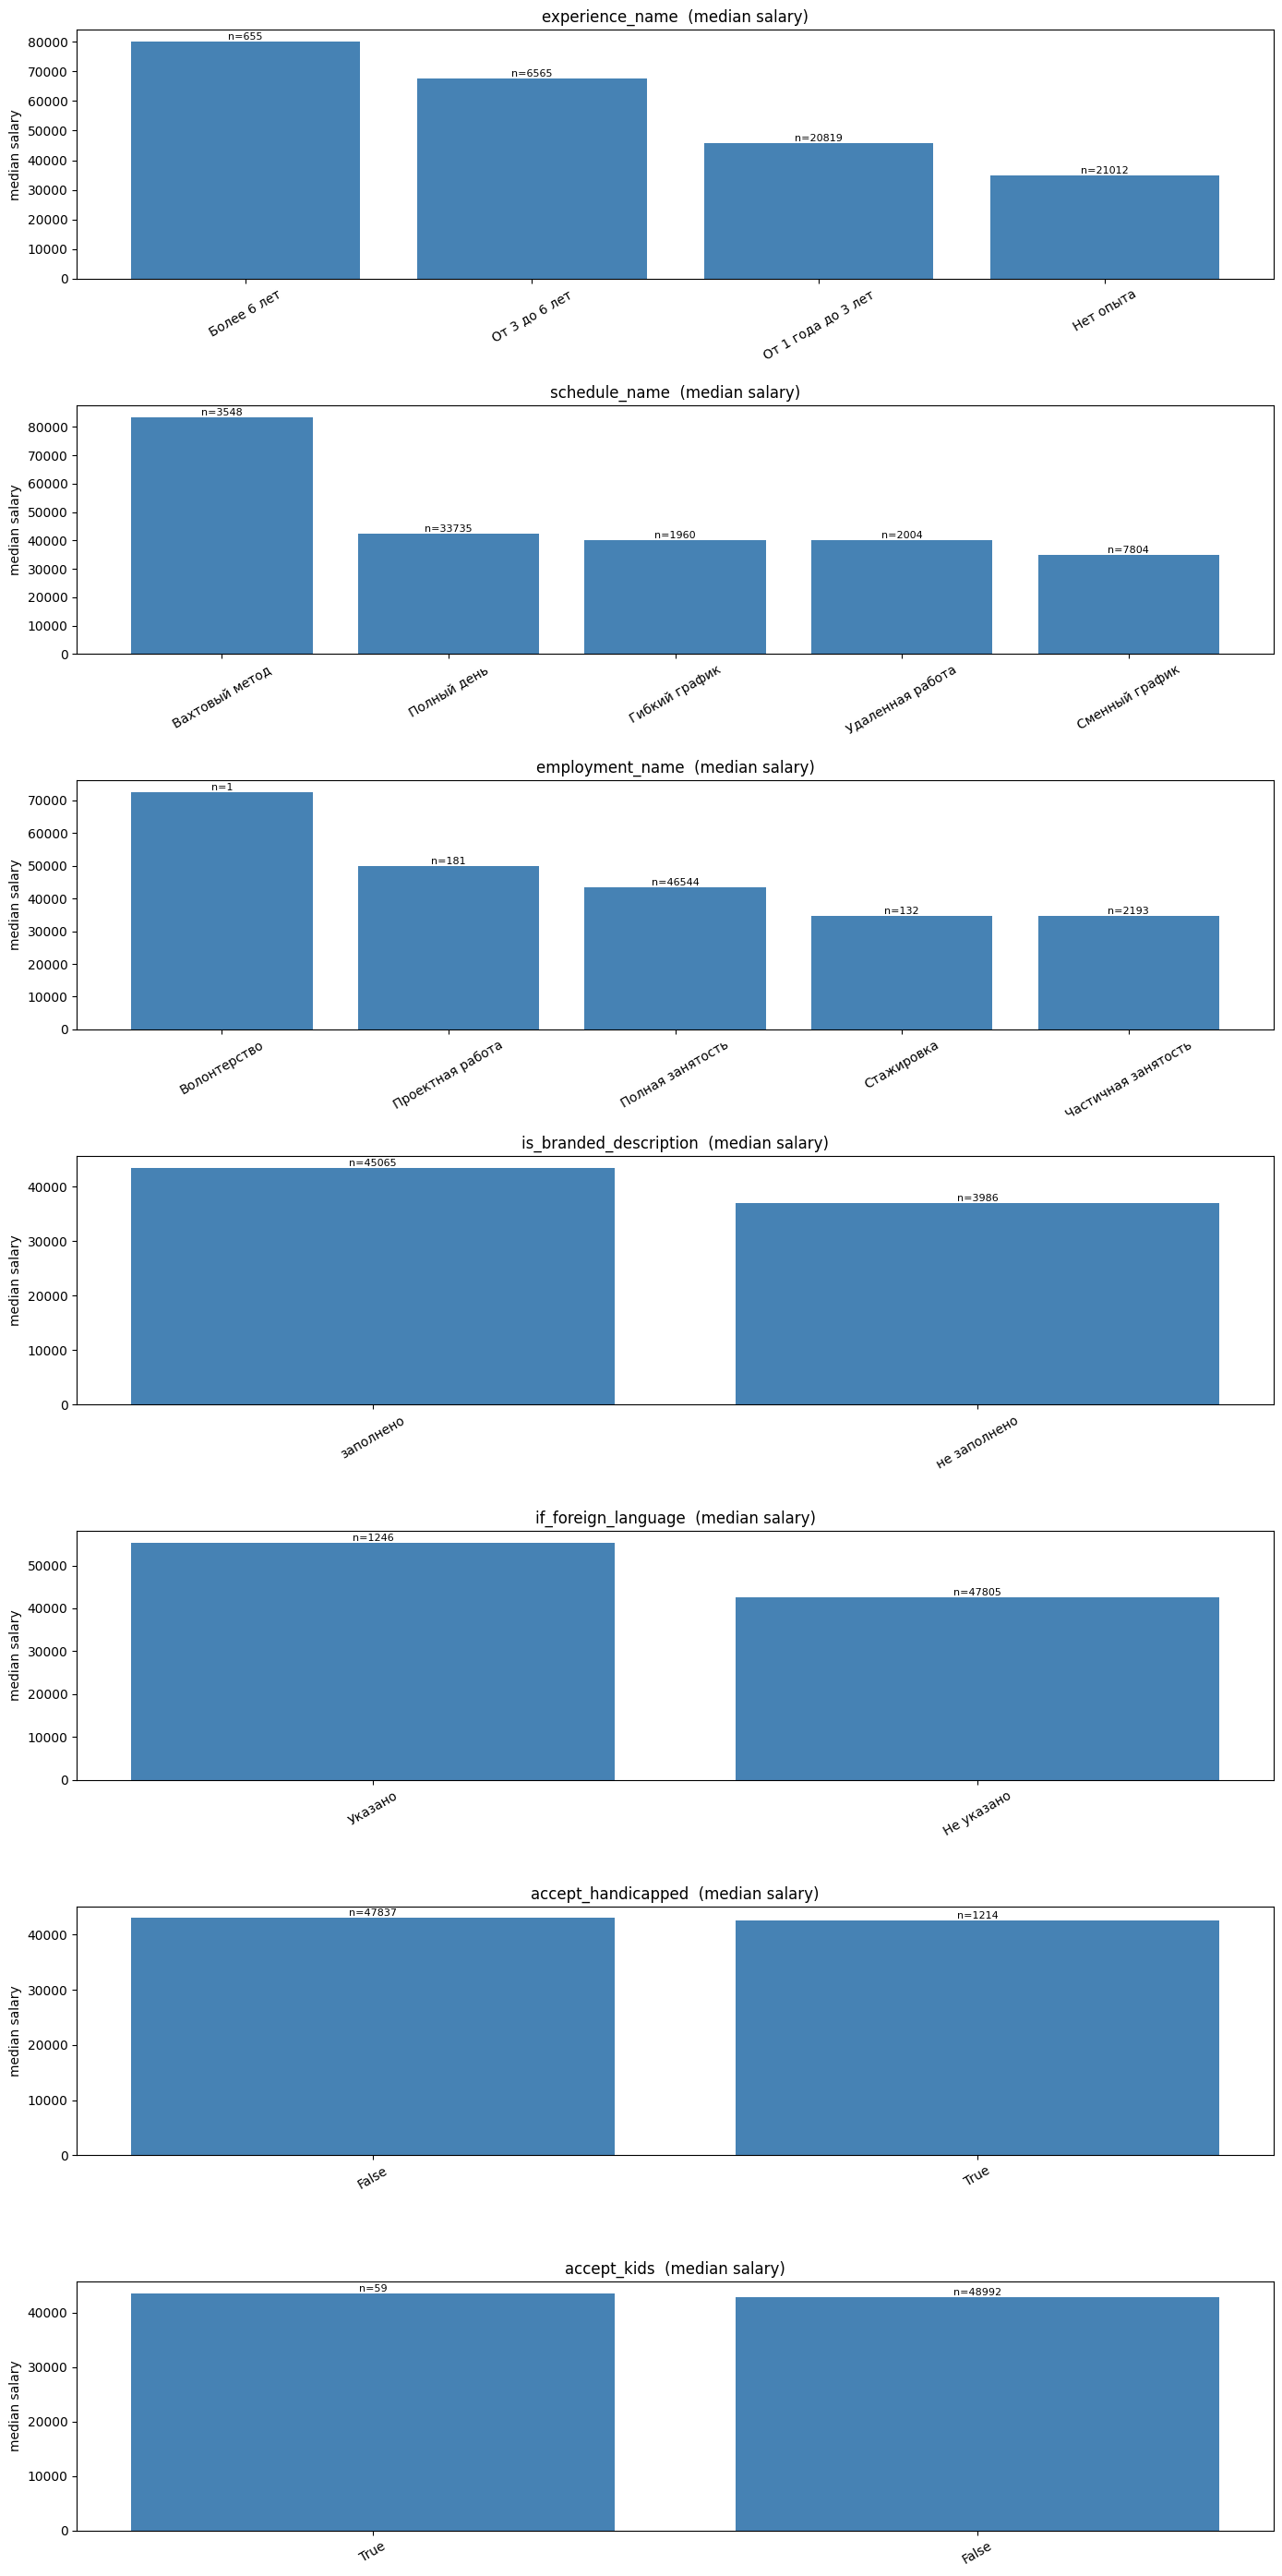

In [7]:
low_card = ['experience_name', 'schedule_name', 'employment_name',
            'is_branded_description', 'if_foreign_language',
            'accept_handicapped', 'accept_kids']

fig, axes = plt.subplots(len(low_card), 1, figsize=(14, 4 * len(low_card)))

for ax, col in zip(axes, low_card):
    stats = (
        train.groupby(col)['salary_mean_net']
        .agg(['median', 'mean', 'count'])
        .sort_values('median', ascending=False)
    )
    bars = ax.bar(stats.index.astype(str), stats['median'], color='steelblue')
    ax.set_title(f'{col}  (median salary)')
    ax.set_ylabel('median salary')
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, stats['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'n={cnt}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 6. High-Cardinality Features — Top-20 by Median Salary

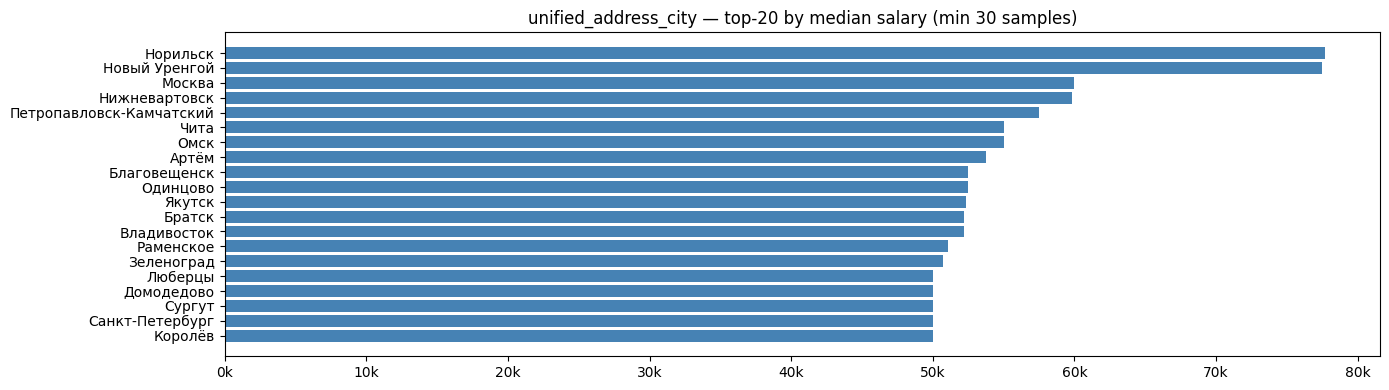

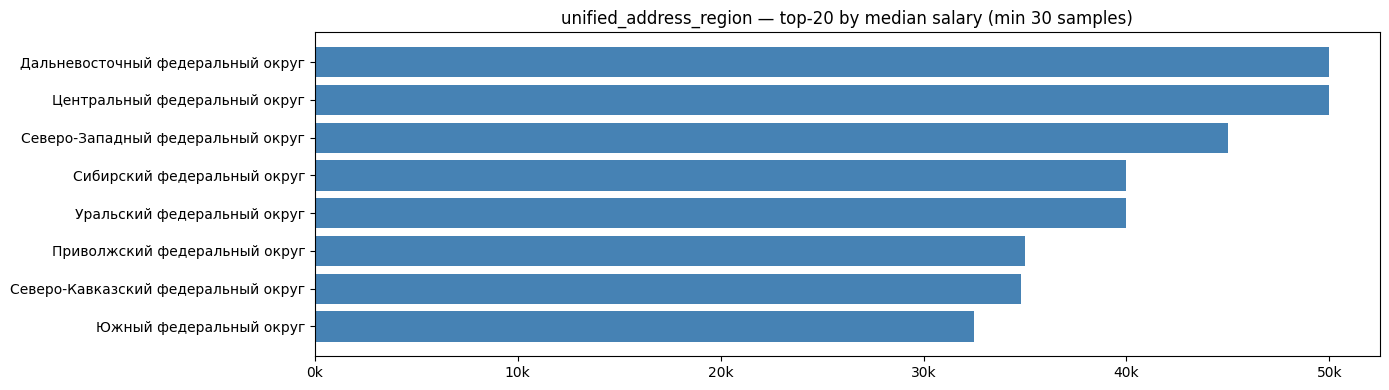

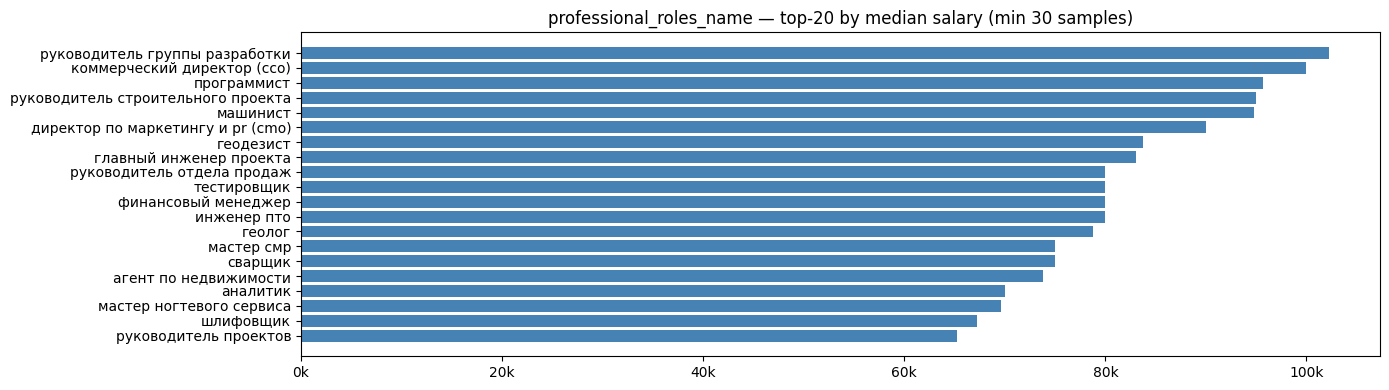

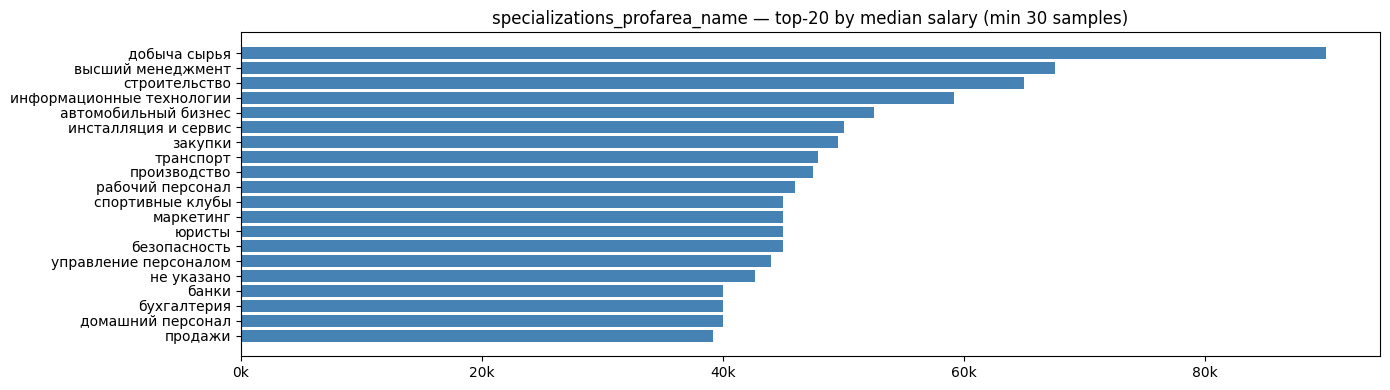

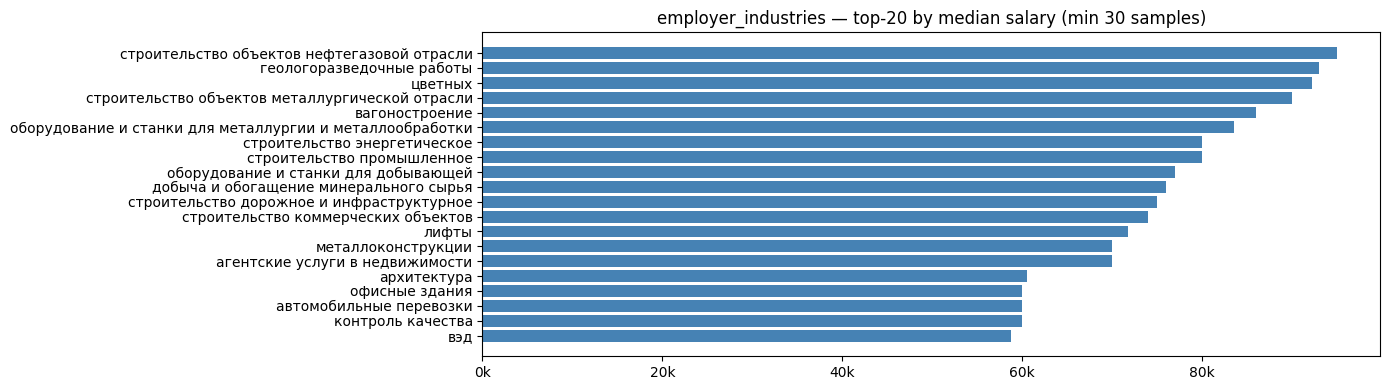

In [8]:
high_card = [
    'unified_address_city', 'unified_address_region',
    'professional_roles_name', 'specializations_profarea_name',
    'employer_industries',
]

for col in high_card:
    stats = (
        train.groupby(col)['salary_mean_net']
        .agg(['median', 'count'])
        .query('count >= 30')
        .sort_values('median', ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.barh(stats.index.astype(str)[::-1], stats['median'][::-1], color='steelblue')
    ax.set_title(f'{col} — top-20 by median salary (min 30 samples)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    plt.tight_layout()
    plt.show()

### 7. Outlier Analysis

In [9]:
thresholds = [100_000, 200_000, 300_000, 500_000, 1_000_000]
for t in thresholds:
    n = (y > t).sum()
    pct = n / len(y) * 100
    print(f'salary > {t:>10,} : {n:>5} rows ({pct:.2f}%)')

print(f'\nTop-10 salaries:')
print(train.nlargest(10, 'salary_mean_net')[['id', 'name', 'employer_name', 'salary_mean_net']].to_string(index=False))

salary >    100,000 :  3187 rows (6.50%)
salary >    200,000 :     0 rows (0.00%)
salary >    300,000 :     0 rows (0.00%)
salary >    500,000 :     0 rows (0.00%)
salary >  1,000,000 :     0 rows (0.00%)

Top-10 salaries:
      id                                                                name                   employer_name  salary_mean_net
46722602 Менеджер по контролю экономики и стратегии (индустриальный холдинг)              Ай - Солюшнс СиАйС         195750.0
49621000                                                   Менеджер проектов                      Консалтика         195750.0
47924602                                             Наставник отдела продаж             Перспектива24-Тверь         195750.0
42424402                                                Директор по продажам Карнаухов Дмитрий Александрович         195750.0
49477000                                    Менеджер по продажам автомобилей        Дилерский центр ABC-AUTO         195750.0
47223801             

### 8. Text Column Analysis

desc_word_cnt stats:
count    49051.0
mean       106.0
std         66.0
min          1.0
5%          29.0
25%         59.0
50%         93.0
75%        138.0
95%        228.0
max        846.0
Name: desc_word_cnt, dtype: float64


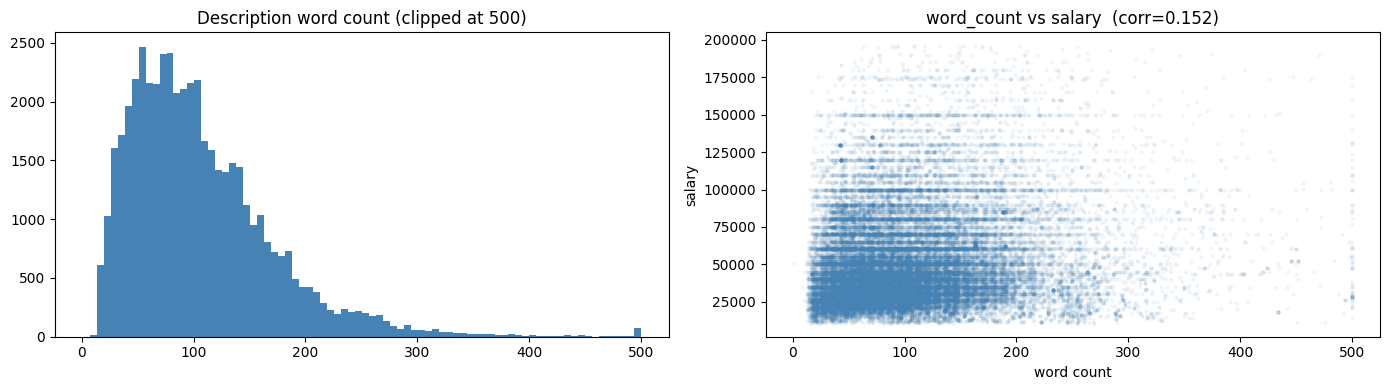

In [10]:
TEXT_COL = 'lemmaized_wo_stopwords_raw_description'

train['desc_len']       = train[TEXT_COL].fillna('').str.len()
train['desc_word_cnt']  = train[TEXT_COL].fillna('').str.split().str.len()

print('desc_word_cnt stats:')
print(train['desc_word_cnt'].describe(percentiles=[.05, .25, .5, .75, .95]).round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train['desc_word_cnt'].clip(upper=500), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Description word count (clipped at 500)')

# correlation with target
corr = train[['desc_word_cnt', 'salary_mean_net']].corr().iloc[0, 1]
axes[1].scatter(train['desc_word_cnt'].clip(upper=500), train['salary_mean_net'].clip(upper=300_000),
                alpha=0.05, s=5, color='steelblue')
axes[1].set_title(f'word_count vs salary  (corr={corr:.3f})')
axes[1].set_xlabel('word count')
axes[1].set_ylabel('salary')

plt.tight_layout()
plt.show()

### 9. Train/Test Distribution Shift Check

In [11]:
check_cols = ['experience_name', 'schedule_name', 'employment_name',
              'unified_address_region', 'professional_roles_name']

for col in check_cols:
    tr_dist = train[col].value_counts(normalize=True).rename('train')
    te_dist = test[col].value_counts(normalize=True).rename('test')
    merged  = pd.concat([tr_dist, te_dist], axis=1).fillna(0)
    # Population Stability Index
    psi = ((merged['train'] - merged['test']) * np.log((merged['train'] + 1e-8) / (merged['test'] + 1e-8))).sum()
    print(f'{col:<40} PSI={psi:.4f}  {"⚠️ SHIFT" if psi > 0.1 else "OK"}')

experience_name                          PSI=0.0005  OK
schedule_name                            PSI=0.0003  OK
employment_name                          PSI=0.0004  OK
unified_address_region                   PSI=0.0004  OK
professional_roles_name                  PSI=0.0151  OK


### 10. Numeric Features Correlation with Target

In [12]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('id', 'salary_mean_net')]

corr_series = train[num_cols + ['salary_mean_net']].corr()['salary_mean_net'].drop('salary_mean_net').sort_values(key=abs, ascending=False)
print('Pearson correlation with salary_mean_net:')
print(corr_series.round(4).to_string())

Pearson correlation with salary_mean_net:
desc_word_cnt    0.1523
desc_len         0.1256
employer_id      0.0034


### 11. `employer_id` — Leakage Check

In [13]:
train_emp = set(train['employer_id'].dropna().unique())
test_emp  = set(test['employer_id'].dropna().unique())

overlap = train_emp & test_emp
print(f'Unique employer_id in train : {len(train_emp)}')
print(f'Unique employer_id in test  : {len(test_emp)}')
print(f'Overlap (train ∩ test)      : {len(overlap)} ({len(overlap)/len(test_emp)*100:.1f}% of test)')

# median salary per employer (only for overlapping)
emp_stats = (
    train[train['employer_id'].isin(overlap)]
    .groupby('employer_id')['salary_mean_net']
    .agg(['median', 'std', 'count'])
)
print(f'\nemployer_id salary stats (overlapping employers):')
print(emp_stats.describe().round(0))

Unique employer_id in train : 23925
Unique employer_id in test  : 7808
Overlap (train ∩ test)      : 3379 (43.3% of test)

employer_id salary stats (overlapping employers):
         median       std   count
count    3379.0    2064.0  3379.0
mean    52677.0   16257.0     7.0
std     27435.0   14045.0    26.0
min     11012.0       0.0     1.0
25%     33675.0    6400.0     1.0
50%     45000.0   12712.0     2.0
75%     65000.0   22553.0     5.0
max    190000.0  106066.0   975.0


### 12. Key Skills & Languages — Presence vs Salary

In [14]:
# key_skills_name and languages_name are stored as string representations of lists
print('key_skills_name sample values:')
print(train['key_skills_name'].dropna().head(5).tolist())
print()
print('languages_name sample values:')
print(train['languages_name'].dropna().head(5).tolist())
print()

# has_skills flag
train['has_skills']    = (train['key_skills_name'].fillna('[]') != '[]').astype(int)
train['has_languages'] = (train['languages_name'].fillna('[]') != '[]').astype(int)

print('Median salary by has_skills:')
print(train.groupby('has_skills')['salary_mean_net'].median().round(0))
print()
print('Median salary by has_languages:')
print(train.groupby('has_languages')['salary_mean_net'].median().round(0))

key_skills_name sample values:
['шитьё', 'организационные навыки', 'работа с большим объемом информации', 'пользователь пк', 'умение работать в коллективе']

languages_name sample values:
['[]', '[]', '[]', '[]', '[]']

Median salary by has_skills:
has_skills
1    42920.0
Name: salary_mean_net, dtype: float64

Median salary by has_languages:
has_languages
0    42500.0
1    55286.0
Name: salary_mean_net, dtype: float64


### 13. Summary & Hypotheses

In [15]:
summary = {
    'train_rows'         : len(train),
    'test_rows'          : len(test),
    'target_median'      : y.median(),
    'target_p99'         : y.quantile(0.99),
    'target_skew'        : y.skew(),
    'pct_salary_gt_500k' : (y > 500_000).mean(),
    'employer_overlap_%' : len(overlap) / len(test_emp),
}
for k, v in summary.items():
    print(f'{k:<30} {v}')

train_rows                     49051
test_rows                      12263
target_median                  42920.0
target_p99                     150000.0
target_skew                    1.5283202572581904
pct_salary_gt_500k             0.0
employer_overlap_%             0.4327612704918033
